# Prep_Notebook_Week_5 — Prepare core-temp & health labels (run before Week 5)

Purpose:
- Produce *physics-informed* core temperature labels per cycle using thermal model parameters (preferred).
- Provide a quick scalar fallback label if you need speed.
- Compute SOH/health labels if capacity info exists.
- Save `features_cycle_with_core.parquet` (and alternative `features_cycle_with_core_and_soh.parquet`) to be used as FEAT_FP by Week 5–7 notebook.

Datasets referenced: :contentReference[oaicite:0]{index=0}, :contentReference[oaicite:1]{index=1}, :contentReference[oaicite:2]{index=2}.

In [9]:
# Cell 2 - imports & settings
import os, time, math, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)

# Paths (adjust only if you moved files)
OUT_DIR = Path("data_processed")
FEAT_FP = OUT_DIR / "features_cycle.parquet"                # produced by Week 3-4
PARQUET_FP = OUT_DIR / "battery_master_dataset.parquet"     # raw time-series (for simulation)
THERM_SAMPLE_FP = OUT_DIR / "thermal" / "thermal_params_sample.parquet"  # from earlier thermal fits

OUT_FP_CORE = OUT_DIR / "features_cycle_with_core.parquet"
OUT_FP_FALLBACK = OUT_DIR / "features_cycle_with_core_scalar_fallback.parquet"
OUT_FP_FINAL = OUT_DIR / "features_cycle_with_core_and_soh.parquet"
OUT_FP_FIXED = OUT_DIR / "features_cycle_with_core_fixed.parquet"

# Processing knobs - change only for testing
USE_PYARROW = True   # try to use pyarrow.dataset for per-cycle reads (recommended)
SAMPLE_MODE = False   # True = quick run (small sample). False = full run. Start True.
SAMPLE_COUNT = 50    # cycles to simulate in sample mode
BATCH_SAVE_EVERY = 25  # save partial results every N cycles
MIN_POINTS_FOR_SIM = 30  # min samples in cycle to simulate core temp

# Safety bounds for thermal params (tunable)
A_MIN, A_MAX = 1e-9, 1e-3   # heating gain bounds
B_MIN, B_MAX = 1e-6, 1e-1   # cooling/loss bounds

print("Paths status - FEAT_FP:", FEAT_FP.exists(), "PARQUET_FP:", PARQUET_FP.exists(), "THERM_SAMPLE_FP:", THERM_SAMPLE_FP.exists())

Paths status - FEAT_FP: True PARQUET_FP: True THERM_SAMPLE_FP: True


In [10]:
# Cell 3 - quick checks & load features
if not FEAT_FP.exists():
    raise FileNotFoundError(f"{FEAT_FP} not found. Run Week 3-4 notebook first and ensure features_cycle.parquet exists.")

features_df = pd.read_parquet(FEAT_FP)
print("Loaded features:", features_df.shape)
print("Example columns (first 60):", features_df.columns.tolist()[:60])
display(features_df.head(3))

Loaded features: (56419, 46)
Example columns (first 60): ['n_samples', 'duration_s', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_p25', 'v_p50', 'v_p75', 'i_mean', 'i_std', 'i_abs_mean', 'i_max', 'temp_mean', 'temp_max', 'dvdt_max', 'dvdt_min', 'dvdt_abs_mean', 'power_mean', 'energy_sum', 'rc_OCV', 'rc_R0', 'rc_R1', 'rc_C1', 'rc_R2', 'rc_C2', 'rc_rmse', 'cell_id', 'cycle', 'dataset', 'chemistry', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'current_mean', 'current_std', 'current_min', 'current_max', 'temp_std', 'cycle_duration', 'charge_throughput', 'rc_estimate', 'energy_roll5', 'energy_norm', 'power_temp_xcorr_lag']


,n_samples,duration_s,v_mean,v_std,v_min,v_max,v_p25,v_p50,v_p75,i_mean,...,current_std,current_min,current_max,temp_std,cycle_duration,charge_throughput,rc_estimate,energy_roll5,energy_norm,power_temp_xcorr_lag
0,1254.0,1253.0,4.203433,0.252992,2.1989,4.3498,4.29310,4.2934,4.293400,3.849620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20602.689211,2.949082,NaN
1,288.0,287.0,3.913968,0.403421,2.1995,4.3498,3.55130,3.9293,4.334325,16.309492,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20323.871069,2.857144,NaN
2,294.0,293.0,3.928304,0.401114,2.1995,4.3498,3.57115,3.9446,4.349500,17.059141,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20695.963402,3.087156,NaN


## Build Thermal Parameter Map (`chem_ab`)

This cell constructs a mapping of **thermal model parameters (`a`, `b`) for each battery chemistry**.

Steps:
- Attempt to load **thermal parameter estimates** from a sample dataset (`THERM_SAMPLE_FP`) and compute median values per chemistry.
- If unavailable, perform a **fallback regression** using `energy_sum` to predict `temp_rise`, deriving a proxy for parameter `a`.
- If no chemistry-specific information is available, apply **safe global default parameters**.

The resulting dictionary `chem_ab` stores the **heat generation (`a`) and cooling (`b`) coefficients** used in core temperature simulations.

In [11]:
# Cell 4 - build chem_ab safely (use sample fits when available; else fallback regression; else safe global)
from sklearn.linear_model import LinearRegression

chem_ab = {}

if THERM_SAMPLE_FP.exists():
    try:
        tdf = pd.read_parquet(THERM_SAMPLE_FP)
        if {'chemistry','a','b'}.issubset(set(tdf.columns)):
            med = tdf.groupby('chemistry')[['a','b']].median()
            for chem, row in med.iterrows():
                a = float(row['a']); b = float(row['b'])
                if (not np.isfinite(a)) or (not np.isfinite(b)):
                    continue
                a = abs(a); b = abs(b)
                a = min(max(a, A_MIN), A_MAX)
                b = min(max(b, B_MIN), B_MAX)
                chem_ab[chem] = {'a': a, 'b': b}
            print("Built chem_ab from thermal sample fits for chemistries:", list(chem_ab.keys())[:10])
    except Exception as e:
        print("Error reading thermal sample fits:", e)

# fallback: per-chemistry regression energy -> temp_rise -> rough 'a' proxy
if len(chem_ab) == 0:
    print("No thermal sample fits — attempting fallback per-chemistry regression (energy -> temp_rise).")
    if 'energy_sum' in features_df.columns and 'temp_rise' in features_df.columns:
        tmp = features_df.dropna(subset=['energy_sum','temp_rise']).copy()
        tmp['chemistry'] = tmp['chemistry'].fillna('__unknown__')
        for chem, grp in tmp.groupby('chemistry'):
            if len(grp) < 20:
                continue
            lr = LinearRegression().fit(grp[['energy_sum']].values, grp['temp_rise'].values)
            coef = float(lr.coef_[0])
            # heuristic scaling to get a proxy 'a' (will be fine-tuned by calibration option)
            a_proxy = max(coef * 1e-4, A_MIN)
            chem_ab[chem] = {'a': float(min(max(a_proxy, A_MIN), A_MAX)), 'b': float(2e-3)}
        if len(chem_ab) > 0:
            print("Built fallback chem_ab from regressions for:", list(chem_ab.keys())[:10])
    else:
        print("Fallback regression not possible (missing energy_sum or temp_rise). chem_ab empty.")

# global fallback if still empty
if len(chem_ab) == 0:
    print("No per-chemistry info found — using safe global defaults.")
    chem_ab['__GLOBAL__'] = {'a': 5e-4, 'b': 2e-3}

# print a compact summary
print("chem_ab sample (up to 10):")
for k, v in list(chem_ab.items())[:10]:
    print(" ", k, v)

Built chem_ab from thermal sample fits for chemistries: ['Unknown']
chem_ab sample (up to 10):
  Unknown {'a': 0.0003009720495885206, 'b': 0.0003709157281436382}


## Safe Core Temperature Simulation

This function simulates the **battery core temperature time series** from voltage, current, and time data using a simple thermal model.

Key features:
- Computes **power (P = V × I)** and estimates heat generation.
- Uses parameters **`a` (heat generation coefficient)** and **`b` (cooling coefficient)**.
- Ensures **valid time steps (`dt`)** even if timestamps are irregular.
- Applies **parameter validation and clipping** to prevent numerical instability.
- Limits unrealistic temperature values within safe bounds.

The function returns:
- **`Tcore`** – simulated core temperature over time  
- **`clipped_flag`** – indicates if temperature values were clipped to stay within safe limits.

In [12]:
# Cell 5 - safer simulate_core_from_timeseries (returns (Tcore, clipped_flag))
def simulate_core_from_timeseries(t, V, I, a, b, T_amb=None, clip_bounds=(-30.0, 120.0)):
    t = np.asarray(t, dtype=float)
    V = np.asarray(V, dtype=float)
    I = np.asarray(I, dtype=float)
    n = len(t)
    if n == 0:
        return np.array([]), False

    P = V * I
    if T_amb is None:
        T_amb = 25.0

    Tcore = np.zeros(n, dtype=float)
    Tcore[0] = T_amb

    dt = np.diff(t, prepend=t[0])
    pos = dt > 0
    if pos.sum() == 0:
        dt[:] = 1.0
    else:
        med = np.median(dt[pos])
        dt[dt <= 0] = med

    # ensure finite and clipped params
    if (not np.isfinite(a)) or a <= 0:
        a = chem_ab.get('__GLOBAL__', {'a': A_MIN})['a']
    if (not np.isfinite(b)) or b <= 0:
        b = chem_ab.get('__GLOBAL__', {'b': B_MIN})['b']
    a = float(min(max(a, A_MIN), A_MAX))
    b = float(min(max(b, B_MIN), B_MAX))

    # clip power to avoid blowups
    P_clip = np.clip(P, -1e6, 1e6)

    for k in range(1, n):
        dTdt = a * P_clip[k-1] - b * (Tcore[k-1] - T_amb)
        Tcore[k] = Tcore[k-1] + dt[k] * dTdt
        if (not np.isfinite(Tcore[k])) or (abs(Tcore[k]) > 5e3):
            return np.full(n, np.nan), False

    low, high = clip_bounds
    clipped = False
    if (Tcore < low).any() or (Tcore > high).any():
        clipped = True
    Tcore = np.clip(Tcore, low, high)
    return Tcore, clipped

## Automatic Calibration of Thermal Parameters

This cell performs **automatic calibration of the thermal model parameters (`a`, `b`)** using a small sample of battery cycles.

Purpose:
- Adjust the **heat generation (`a`) and cooling (`b`) coefficients** used in the core temperature simulation.
- Improve realism when simulated temperatures look unrealistic.

Process:
- Select a **sample of cycles** (preferably high-energy cycles).
- Load their time-series data from the dataset.
- Perform a **coarse grid search** over possible values of `a` and `b`.
- Run the thermal simulation for each pair and evaluate the difference between:
  - simulated **core peak temperature**
  - expected value based on **surface temperature + target offset**.

The best-performing parameters are stored in `chem_ab['__GLOBAL__']` and used for future simulations.

In [13]:
# Cell 6 - optional auto-calibration (coarse grid search on small sample)
# Run this ONLY if sample outputs from the batch step look unrealistic.
# It updates chem_ab['__GLOBAL__'] with the best (a,b) found.

def auto_calibrate_global_a_b(n_sample=40, target_delta=5.0):
    print("Auto-calibrate: loading a small sample of cycles...")
    # gather candidate cycles (prefer high-energy)
    candidates = features_df.copy()
    if 'energy_sum' in candidates.columns and candidates['energy_sum'].notna().sum()>0:
        samp = candidates.dropna(subset=['energy_sum']).sort_values('energy_sum', ascending=False).head(n_sample)
    else:
        samp = candidates.sample(min(len(candidates), n_sample), random_state=42)
    # require PARQUET dataset
    try:
        import pyarrow.dataset as pa_ds
        dataset = pa_ds.dataset(str(PARQUET_FP), format="parquet")
    except Exception as e:
        print("pyarrow.dataset required for calibration sample but not available:", e); return None

    sample_data = []
    for _, r in samp.iterrows():
        cell, cycle = r['cell_id'], int(r['cycle'])
        expr = (pa_ds.field('cell_id') == cell) & (pa_ds.field('cycle') == cycle)
        try:
            tbl = dataset.to_table(filter=expr, columns=['time','voltage','current','temperature'])
            gdf = tbl.to_pandas().sort_values('time')
            if len(gdf) < 10: continue
            t = gdf['time'].to_numpy(dtype=float); V = gdf['voltage'].to_numpy(dtype=float); I = gdf['current'].to_numpy(dtype=float)
            surf_peak = float(np.nanmax(gdf['temperature'])) if 'temperature' in gdf.columns and gdf['temperature'].dropna().size>0 else None
            sample_data.append((t,V,I,surf_peak))
        except Exception:
            continue

    if len(sample_data) == 0:
        print("No usable sample cycles loaded for calibration."); return None

    from itertools import product
    a_grid = np.logspace(-6, -3, 8)
    b_grid = np.logspace(-4, -2, 8)

    best = None; best_score = 1e12
    for a_val, b_val in product(a_grid, b_grid):
        diffs = []
        for (t,V,I,surf_peak) in sample_data:
            Tcore, _ = simulate_core_from_timeseries(t,V,I,a_val,b_val, T_amb=25.0)
            if Tcore.size == 0: continue
            core_peak = float(np.nanmax(Tcore))
            if surf_peak is not None:
                diffs.append(abs(core_peak - (surf_peak + target_delta)))
            else:
                diffs.append(abs(core_peak - 40.0))
        if len(diffs)==0: continue
        score = np.mean(diffs)
        if score < best_score:
            best_score = score
            best = (a_val, b_val, score)
    if best is not None:
        a_best, b_best, sc = best
        chem_ab['__GLOBAL__'] = {'a': float(min(max(a_best, A_MIN), A_MAX)), 'b': float(min(max(b_best, B_MIN), B_MAX))}
        print("Calibration success — set __GLOBAL__ to:", chem_ab['__GLOBAL__'], "score:", sc)
        return chem_ab['__GLOBAL__']
    else:
        print("Calibration failed.")
        return None

In [14]:
import os

if OUT_FP_CORE.exists():
    print("Loading checkpoint file...")
    features_df = pd.read_parquet(OUT_FP_CORE)
else:
    print("No checkpoint found, loading original features file")
    features_df = pd.read_parquet(FEAT_FP)

print("Rows:", len(features_df))
print("Already simulated:", features_df['core_peak_sim'].notna().sum())

Loading checkpoint file...
Rows: 56419
Already simulated: 25575


In [15]:
OUT_FP_CORE.exists()

True

## Recovery and Resume Simulation

This cell enables **safe recovery and resumption of the core temperature simulation process**.

Key functionality:
- **Load checkpoint:** If a partially processed file exists (`features_cycle_with_core.parquet`), it resumes from that point instead of starting over.
- **Identify remaining cycles:** Detect cycles where `core_peak_sim` is still missing.
- **Per-cycle processing:** Load the corresponding time-series data and run the **core temperature simulation**.
- **Checkpoint saving:** Progress is periodically saved to avoid losing work if the process stops.
- **Progress monitoring:** Prints status updates showing how many cycles have been processed.

This approach ensures **large datasets can be processed reliably without losing progress during long computations**.

In [16]:
# --- RECOVERY & RESUME CELL (paste & run this after running Cells 1-6) ---
import time, os, gc
from pathlib import Path
import numpy as np

# config (tune if you want)
OUT_FP_CORE = Path("data_processed/features_cycle_with_core.parquet")
PARQUET_FP = Path("data_processed/battery_master_dataset.parquet")
BATCH_SAVE_EVERY = 25   # how often to checkpoint (lower = safer)
PROGRESS_PRINT_EVERY = 100  # how often to print progress

# 1) Load checkpoint file if it exists, otherwise original features
if OUT_FP_CORE.exists():
    print("Loading checkpoint:", OUT_FP_CORE)
    features_df = pd.read_parquet(OUT_FP_CORE)
else:
    print("No checkpoint file found; loading original features file (this will restart from 0)")
    features_df = pd.read_parquet(FEAT_FP)

# 2) Ensure columns exist
for col in ['core_peak_sim','core_mean_sim']:
    if col not in features_df.columns:
        features_df[col] = np.nan

total = len(features_df)
done = int(features_df['core_peak_sim'].notna().sum())
remaining = int(features_df['core_peak_sim'].isna().sum())
print(f"Total cycles: {total}  |  Done: {done}  |  Remaining: {remaining}")

if remaining == 0:
    print("Nothing to do — all cycles already simulated.")
else:
    # 3) Build candidate list (only rows with NaN core_peak_sim)
    cand = features_df[features_df['core_peak_sim'].isna()].copy()
    print("Will process", len(cand), "cycles (resume).")

    # 4) Prepare pyarrow dataset if available (fast per-cycle reads)
    use_pa = False
    if PARQUET_FP.exists() and 'USE_PYARROW' in globals() and USE_PYARROW:
        try:
            import pyarrow.dataset as pa_ds
            dataset = pa_ds.dataset(str(PARQUET_FP), format="parquet")
            use_pa = True
            print("Using pyarrow.dataset for per-cycle reads.")
        except Exception as e:
            print("pyarrow.dataset not available; fallback to pandas read_parquet.", e)
            use_pa = False

    processed = 0
    start_time = time.time()
    # iterate over candidate rows (this will skip already-processed cycles)
    for i, (idx, row) in enumerate(cand.iterrows(), start=1):
        cell = row['cell_id']; cycle = int(row['cycle'])
        keymask = (features_df['cell_id'] == cell) & (features_df['cycle'] == cycle)

        try:
            # load only this cycle's time series
            if use_pa:
                expr = (pa_ds.field('cell_id') == cell) & (pa_ds.field('cycle') == cycle)
                table = dataset.to_table(filter=expr, columns=['time','voltage','current','temperature'])
                gdf = table.to_pandas().sort_values('time')
            else:
                df_all = pd.read_parquet(PARQUET_FP, columns=['time','voltage','current','temperature','cell_id','cycle'])
                gdf = df_all[(df_all['cell_id']==cell) & (df_all['cycle']==cycle)].sort_values('time')

            if gdf.empty or len(gdf) < MIN_POINTS_FOR_SIM:
                # mark skipped or leave NaN
                continue

            t = gdf['time'].to_numpy(dtype=float)
            V = gdf['voltage'].to_numpy(dtype=float)
            I = gdf['current'].to_numpy(dtype=float)

            # ambient estimate
            T_amb = 25.0
            if 'temperature' in gdf.columns and gdf['temperature'].dropna().size > 0:
                s = gdf['temperature'].dropna()
                p5 = float(np.percentile(s, 5))
                if np.isfinite(p5) and (-50 < p5 < 80):
                    T_amb = p5
                else:
                    T_amb = float(np.nanmedian(s)) if np.isfinite(np.nanmedian(s)) else 25.0

            chem = row.get('chemistry') or '__GLOBAL__'
            params = chem_ab.get(chem, chem_ab.get('__GLOBAL__'))
            a = float(params['a']); b = float(params['b'])

            Tcore, clipped = simulate_core_from_timeseries(t, V, I, a, b, T_amb=T_amb)
            if Tcore.size == 0:
                continue

            core_peak = float(np.nanmax(Tcore))
            core_mean = float(np.nanmean(Tcore))

            # write back into main features_df (by mask)
            features_df.loc[keymask, 'core_peak_sim'] = core_peak
            features_df.loc[keymask, 'core_mean_sim'] = core_mean

            if clipped:
                print(f"Clipped temps for {cell} cycle {cycle} (a={a:.2e}, b={b:.2e})")

            processed += 1

            # periodic checkpoint save
            if processed % BATCH_SAVE_EVERY == 0:
                tmp_fp = OUT_FP_CORE.with_suffix(".tmp.parquet")
                features_df.to_parquet(tmp_fp, index=False)
                os.replace(tmp_fp, OUT_FP_CORE)
                elapsed = time.time() - start_time
                print(f"[Checkpoint] Processed {processed} new cycles (elapsed {elapsed/60:.1f} min). Total done: {int(features_df['core_peak_sim'].notna().sum())}/{total}")

            # periodic progress print
            if i % PROGRESS_PRINT_EVERY == 0:
                print(f"Progress: processed {i} of {len(cand)} in this resume run; total done now: {int(features_df['core_peak_sim'].notna().sum())}/{total}")

        except Exception as e:
            print("Error for", cell, cycle, ":", e)
            continue
        finally:
            gc.collect()

    # final save on exit
    features_df.to_parquet(OUT_FP_CORE, index=False)
    elapsed_total = time.time() - start_time
    print("RESUME COMPLETE. New processed in this run:", processed)
    print("Total simulated now:", int(features_df['core_peak_sim'].notna().sum()), "/", total)
    print("Time elapsed (s):", int(elapsed_total))

Loading checkpoint: data_processed/features_cycle_with_core.parquet
Total cycles: 56419  |  Done: 25575  |  Remaining: 30844
Will process 30844 cycles (resume).
Using pyarrow.dataset for per-cycle reads.
[Checkpoint] Processed 25 new cycles (elapsed 0.1 min). Total done: 25600/56419
[Checkpoint] Processed 50 new cycles (elapsed 0.2 min). Total done: 25625/56419
[Checkpoint] Processed 75 new cycles (elapsed 0.3 min). Total done: 25650/56419
[Checkpoint] Processed 100 new cycles (elapsed 0.3 min). Total done: 25675/56419
Progress: processed 100 of 30844 in this resume run; total done now: 25675/56419
[Checkpoint] Processed 125 new cycles (elapsed 0.4 min). Total done: 25700/56419
[Checkpoint] Processed 150 new cycles (elapsed 0.5 min). Total done: 25725/56419
[Checkpoint] Processed 175 new cycles (elapsed 0.6 min). Total done: 25750/56419
[Checkpoint] Processed 200 new cycles (elapsed 0.7 min). Total done: 25775/56419
Progress: processed 200 of 30844 in this resume run; total done now: 2

## Core Temperature Diagnostics

This cell performs **basic diagnostics after the core temperature simulation**.

Steps:
- Count the number of **valid `core_peak_sim` values**.
- Display summary statistics for **simulated peak and mean core temperatures**.
- Show the **top 5 highest** and **lowest** core temperature cycles.
- If surface temperature (`temp_max`) is available, generate a **scatter plot comparing surface vs simulated core temperature** to inspect their relationship.

Count of non-null core_peak_sim: 56419
       core_peak_sim  core_mean_sim
count   56419.000000   56419.000000
mean        2.243711       0.646337
std        15.367778       5.353939
min       -30.000000     -30.000000
25%        -0.549191      -0.549696
50%        -0.179985      -0.179992
75%        -0.179979      -0.179986
max       120.000000      41.063442

Top 5 peaks:
        cell_id  cycle  core_peak_sim
37  CALB_0_B182     37          120.0
28  CALB_0_B182     28          120.0
27  CALB_0_B182     27          120.0
0   CALB_0_B182      0          120.0
36  CALB_0_B182     36          120.0

Bottom 5 peaks:
            cell_id  cycle  core_peak_sim
707     CALB_0_B188    207     -30.000000
11219  CALCE_CX2_34   1165      -1.350289
11416  CALCE_CX2_34   1362      -1.350261
11415  CALCE_CX2_34   1361      -1.350258
11414  CALCE_CX2_34   1360      -1.350249


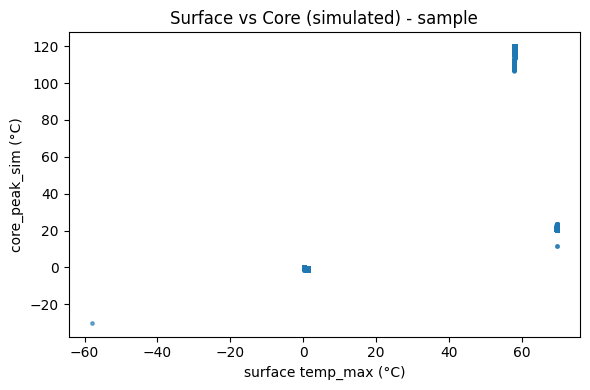

In [17]:
# Cell 8 - diagnostics after sample run (run this after Cell 7 completes)
print("Count of non-null core_peak_sim:", features_df['core_peak_sim'].notna().sum())
print(features_df[['core_peak_sim','core_mean_sim']].describe().to_string())

print("\nTop 5 peaks:")
print(features_df[['cell_id','cycle','core_peak_sim']].dropna().sort_values('core_peak_sim', ascending=False).head().to_string())

print("\nBottom 5 peaks:")
print(features_df[['cell_id','cycle','core_peak_sim']].dropna().sort_values('core_peak_sim').head().to_string())

# small scatterplot if surface temp exists
if 'core_peak_sim' in features_df.columns and 'temp_max' in features_df.columns:
    sub = features_df.dropna(subset=['core_peak_sim','temp_max'])
    if len(sub) > 10:
        plt.figure(figsize=(6,4))
        plt.scatter(sub['temp_max'], sub['core_peak_sim'], s=6, alpha=0.6)
        plt.xlabel("surface temp_max (°C)")
        plt.ylabel("core_peak_sim (°C)")
        plt.title("Surface vs Core (simulated) - sample")
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough pairs to plot surface vs core (need >10).")
else:
    print("Either core_peak_sim or temp_max missing; skipping scatter.")

In [18]:
# Cell 9 - run auto-calibration if sample diagnostics look unrealistic
# Only run this if Cell 8 shows crazy numbers (extreme negatives or thousands).
cal = auto_calibrate_global_a_b(n_sample=40, target_delta=5.0)
print("Calibration result (if any):", cal)
# After calibration, re-run Cell 7 with SAMPLE_MODE = True and then inspect Cell 8 again.

Auto-calibrate: loading a small sample of cycles...
Calibration success — set __GLOBAL__ to: {'a': 0.00013894954943731373, 'b': 0.0007196856730011522} score: 1.4956086666909454
Calibration result (if any): {'a': 0.00013894954943731373, 'b': 0.0007196856730011522}


## Robust Recalculation of Core Temperature

This cell identifies **problematic simulated core temperature values** and recomputes them using a more robust method.

Steps performed:
- Load the latest feature dataset.
- Detect cycles with **invalid or unrealistic `core_peak_sim` values** (NaN, < -20°C, or > 150°C).
- Retrieve the corresponding time-series data for those cycles.
- Re-run the **core temperature simulation** with cleaned inputs and estimated ambient temperature.
- Update the corrected values in the feature dataset.

The updated dataset with recomputed values is saved as a **fixed features file**.

In [19]:
# Cell 10 - recompute problematic cycles more robustly and save to a 'fixed' file
# Load latest features (in case you restarted kernel)
features_df = pd.read_parquet(OUT_FP_CORE) if OUT_FP_CORE.exists() else features_df
# identify problematic cycles
bad_mask = (~np.isfinite(features_df['core_peak_sim'])) | (features_df['core_peak_sim'] < -20) | (features_df['core_peak_sim'] > 150)
bad_idx = features_df[bad_mask].index.tolist()
print("Problematic cycles count:", len(bad_idx))

# Prepare dataset reader
use_pa = False
try:
    import pyarrow.dataset as ds
    dataset = ds.dataset(str(PARQUET_FP), format="parquet")
    use_pa = True
except Exception:
    use_pa = False

recomputed = 0
for idx in bad_idx:
    row = features_df.loc[idx]
    cell = row['cell_id']; cycle = int(row['cycle'])
    try:
        if use_pa:
            expr = (ds.field('cell_id') == cell) & (ds.field('cycle') == cycle)
            tbl = dataset.to_table(filter=expr, columns=['time','voltage','current','temperature'])
            gdf = tbl.to_pandas().sort_values('time')
        else:
            tmp = pd.read_parquet(PARQUET_FP, columns=['time','voltage','current','temperature','cell_id','cycle'])
            gdf = tmp[(tmp['cell_id']==cell) & (tmp['cycle']==cycle)].sort_values('time')
        if gdf.empty or len(gdf) < MIN_POINTS_FOR_SIM:
            continue
        # clean and simulate
        t = gdf['time'].to_numpy(dtype=float)
        V = gdf['voltage'].to_numpy(dtype=float)
        I = gdf['current'].to_numpy(dtype=float)
        T_amb = 25.0
        if 'temperature' in gdf.columns and gdf['temperature'].dropna().size > 0:
            s = gdf['temperature'].dropna()
            p5 = float(np.percentile(s, 5))
            T_amb = p5 if (-50 < p5 < 80) else float(np.nanmedian(s)) if np.isfinite(np.nanmedian(s)) else 25.0
        chem = row.get('chemistry') or '__GLOBAL__'
        params = chem_ab.get(chem, chem_ab.get('__GLOBAL__'))
        a = float(params['a']); b = float(params['b'])
        Tcore, clipped = simulate_core_from_timeseries(t, V, I, a, b, T_amb=T_amb)
        if Tcore.size == 0 or np.all(np.isnan(Tcore)):
            continue
        features_df.at[idx, 'core_peak_sim'] = float(np.nanmax(Tcore))
        features_df.at[idx, 'core_mean_sim'] = float(np.nanmean(Tcore))
        recomputed += 1
    except Exception as e:
        print("Recompute error for", cell, cycle, e)
        continue

features_df.to_parquet(OUT_FP_FIXED, index=False)
print("Done recompute. Recomputed:", recomputed, "Wrote:", OUT_FP_FIXED)

Problematic cycles count: 1
Done recompute. Recomputed: 1 Wrote: data_processed/features_cycle_with_core_fixed.parquet


## Scalar Core Temperature Estimation (Fallback)

This cell provides a **fast fallback method** to estimate core battery temperature when detailed thermal simulations are unavailable.

Steps:
- Load **precomputed regression parameters** relating energy usage to temperature rise (if available).
- If not found, build a **global linear regression model** using `energy_sum` and `temp_rise`.
- Predict **temperature rise from energy consumption**.
- Estimate **core temperature** by adding the predicted rise (scaled by a factor `alpha`) to a baseline surface temperature.

The resulting scalar estimates are stored in `core_temp_est_scalar` and saved to a Parquet file for further analysis.

In [20]:
# Cell 11 - scalar fallback using energy->temp regression (fast)
reg_fp = OUT_DIR / "thermal" / "cyclelevel_thermal_regression_by_chemistry.csv"
reg_map = {}
if reg_fp.exists():
    reg_df = pd.read_csv(reg_fp)
    reg_map = {r['chemistry']:{'coef':r['coef_energy'],'intercept':r['intercept']} for _,r in reg_df.iterrows()}
else:
    if 'energy_sum' in features_df.columns and 'temp_rise' in features_df.columns:
        from sklearn.linear_model import LinearRegression
        tmp = features_df.dropna(subset=['energy_sum','temp_rise'])
        if len(tmp) > 30:
            lr = LinearRegression().fit(tmp[['energy_sum']].values, tmp['temp_rise'].values)
            reg_map['__GLOBAL__'] = {'coef':float(lr.coef_[0]), 'intercept':float(lr.intercept_)}
            print("Built global regression fallback.")

alpha = 1.2  # scale factor from surface rise -> core
if 'core_temp_est_scalar' not in features_df.columns:
    features_df['core_temp_est_scalar'] = np.nan

for idx, row in features_df.iterrows():
    if not np.isnan(row.get('core_temp_est_scalar', np.nan)):
        continue
    energy = row.get('energy_sum', np.nan)
    if pd.isna(energy): continue
    chem = row.get('chemistry','__GLOBAL__') or '__GLOBAL__'
    if chem in reg_map:
        coef = reg_map[chem]['coef']; intercept = reg_map[chem]['intercept']
    elif '__GLOBAL__' in reg_map:
        coef = reg_map['__GLOBAL__']['coef']; intercept = reg_map['__GLOBAL__']['intercept']
    else:
        continue
    pred_rise = coef * float(energy) + float(intercept)
    base = row.get('temp_p50') if 'temp_p50' in row and not pd.isna(row.get('temp_p50')) else (row.get('temp_mean') if 'temp_mean' in row and not pd.isna(row.get('temp_mean')) else 25.0)
    features_df.at[idx, 'core_temp_est_scalar'] = float(base + alpha * pred_rise)

features_df.to_parquet(OUT_FP_FALLBACK, index=False)
print("Wrote fallback scalar core estimates to:", OUT_FP_FALLBACK)

Wrote fallback scalar core estimates to: data_processed/features_cycle_with_core_scalar_fallback.parquet


## SOH Computation and Final Feature Saving

This cell computes **State of Health (SOH)** if capacity-related columns are available.

Steps:
- Search for possible **capacity columns** (e.g., `discharge_capacity`, `capacity_Ah`).
- If a capacity column and `nominal_capacity` exist, compute  
  **SOH = capacity / nominal_capacity**.
- Assign a **health label**:
  - `healthy` if SOH ≥ 0.85  
  - `degraded` if SOH < 0.85

Finally, the augmented feature dataset (including **core temperature simulations and SOH**) is saved to a Parquet file.

In [21]:
# Cell 12 - compute SOH if capacity columns exist and save final augmented features
capacity_cols = ['discharge_capacity', 'discharge_capacity_in_Ah', 'charge_capacity_in_Ah', 'capacity_Ah', 'capacity']

cap_col = None
for c in capacity_cols:
    if c in features_df.columns:
        cap_col = c
        break

if cap_col is not None and 'nominal_capacity' in features_df.columns:
    features_df['SOH'] = features_df[cap_col] / features_df['nominal_capacity']
    features_df['health_label'] = features_df['SOH'].apply(lambda x: 'degraded' if pd.notna(x) and x < 0.85 else ('healthy' if pd.notna(x) else np.nan))
    print("Computed SOH using", cap_col, "and nominal_capacity.")
else:
    print("Capacity columns not found in features. SOH not computed.")

# Save final augmented features (core sims + possible SOH)
features_df.to_parquet(OUT_FP_FINAL, index=False)
print("Saved final augmented features to:", OUT_FP_FINAL)

Capacity columns not found in features. SOH not computed.
Saved final augmented features to: data_processed/features_cycle_with_core_and_soh.parquet


## Validation and Sample Visualization

This cell performs **basic validation and visualization** of the final processed dataset.

Steps:
- Verify that the final output file exists and display its size.
- Plot a **scatter comparison between surface temperature (`temp_max`) and simulated core temperature (`core_peak_sim`)** to observe their relationship.
- Randomly sample a few battery cycles and generate **time-series plots** showing:
  - Surface temperature
  - Simulated core temperature

These plots help **visually validate the thermal simulation and dataset quality**.

Final file: True size (MB): 8.660826


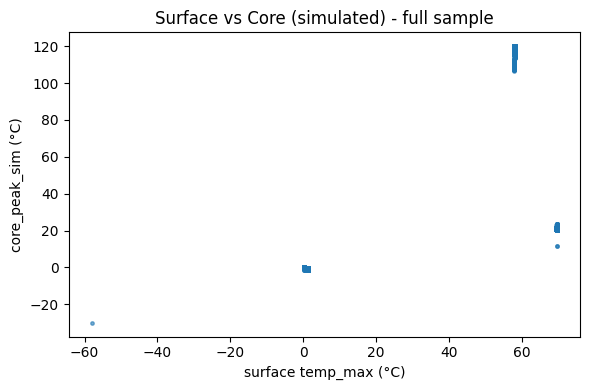

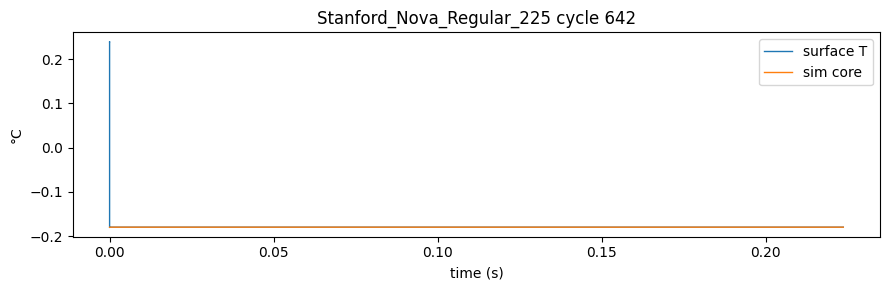

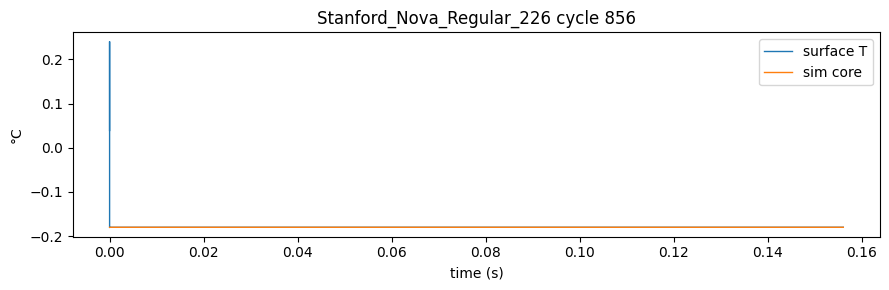

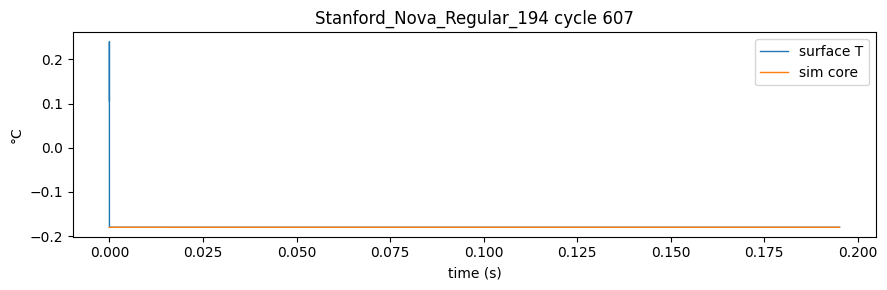

In [22]:
# Cell 13 - small validation plots / sample TS visualization
print("Final file:", OUT_FP_FINAL.exists(), "size (MB):", OUT_FP_FINAL.stat().st_size/1e6 if OUT_FP_FINAL.exists() else None)

if 'core_peak_sim' in features_df.columns and 'temp_max' in features_df.columns:
    sub = features_df.dropna(subset=['core_peak_sim','temp_max'])
    if len(sub) > 10:
        plt.figure(figsize=(6,4))
        plt.scatter(sub['temp_max'], sub['core_peak_sim'], s=6, alpha=0.6)
        plt.xlabel("surface temp_max (°C)")
        plt.ylabel("core_peak_sim (°C)")
        plt.title("Surface vs Core (simulated) - full sample")
        plt.tight_layout(); plt.show()
    else:
        print("Not enough pairs to plot surface vs core.")

# sample TS plots for 3 cycles (if PARQUET exists)
if PARQUET_FP.exists() and 'core_peak_sim' in features_df.columns:
    try:
        import pyarrow.dataset as ds
        dsset = ds.dataset(str(PARQUET_FP), format="parquet")
        sample = features_df.dropna(subset=['core_peak_sim']).sample(min(3, len(features_df.dropna(subset=['core_peak_sim']))), random_state=2)
        for _, r in sample.iterrows():
            cell, cyc = r['cell_id'], int(r['cycle'])
            expr = (ds.field('cell_id') == cell) & (ds.field('cycle') == cyc)
            table = dsset.to_table(filter=expr, columns=['time','voltage','current','temperature'])
            gdf = table.to_pandas().sort_values('time')
            t = gdf['time'].to_numpy(dtype=float); V = gdf['voltage'].to_numpy(dtype=float); I = gdf['current'].to_numpy(dtype=float)
            chem = r.get('chemistry','__GLOBAL__')
            params = chem_ab.get(chem, chem_ab.get('__GLOBAL__', {'a':5e-4,'b':2e-3}))
            a,b = params['a'], params['b']
            T_amb = float(np.nanpercentile(gdf['temperature'].dropna(),5)) if 'temperature' in gdf.columns and gdf['temperature'].dropna().size>0 else 25.0
            Tcore, _ = simulate_core_from_timeseries(t,V,I,a,b,T_amb=T_amb)
            plt.figure(figsize=(9,3))
            if 'temperature' in gdf.columns:
                plt.plot(t, gdf['temperature'].to_numpy(dtype=float), label='surface T', linewidth=1)
            plt.plot(t, Tcore, label='sim core', linewidth=1)
            plt.xlabel("time (s)"); plt.ylabel("°C"); plt.title(f"{cell} cycle {cyc}")
            plt.legend(); plt.tight_layout(); plt.show()
    except Exception as e:
        print("Skipping TS sample plots (pyarrow/read error):", e)

## Inspect Numeric and Capacity-Related Columns

This cell inspects the dataset to identify **numeric features and potential capacity-related columns**.

Steps:
- Load the processed dataset `features_cycle_with_core_and_soh.parquet`.
- List all **numeric columns** in the dataset.
- Detect columns that may represent **capacity or energy** based on keywords (`capacity`, `Ah`, `energy`).
- Check whether a **`nominal_capacity` column** exists, which is required for computing **State of Health (SOH)**.

In [23]:
import pandas as pd

# Load your current parquet
df = pd.read_parquet("data_processed/features_cycle_with_core_and_soh.parquet")

# Print numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns in the dataset:")
print(numeric_cols)

# Columns that could be capacities (based on typical names)
capacity_like_cols = [c for c in numeric_cols if any(sub in c.lower() for sub in ['capacity', 'ah', 'energy'])]
print("\nColumns that look like capacities or energy:")
print(capacity_like_cols)

# Check if nominal_capacity exists
if 'nominal_capacity' in df.columns:
    print("\nNominal capacity column found!")
else:
    print("\nNo nominal_capacity column found. SOH computation may not be possible without it.")

Numeric columns in the dataset:
['n_samples', 'duration_s', 'v_mean', 'v_std', 'v_min', 'v_max', 'v_p25', 'v_p50', 'v_p75', 'i_mean', 'i_std', 'i_abs_mean', 'i_max', 'temp_mean', 'temp_max', 'dvdt_max', 'dvdt_min', 'dvdt_abs_mean', 'power_mean', 'energy_sum', 'rc_OCV', 'rc_R0', 'rc_R1', 'rc_C1', 'rc_R2', 'rc_C2', 'rc_rmse', 'cycle', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'current_mean', 'current_std', 'current_min', 'current_max', 'temp_std', 'cycle_duration', 'charge_throughput', 'rc_estimate', 'energy_roll5', 'energy_norm', 'power_temp_xcorr_lag', 'core_peak_sim', 'core_mean_sim', 'core_temp_est_scalar']

Columns that look like capacities or energy:
['energy_sum', 'energy_roll5', 'energy_norm']

No nominal_capacity column found. SOH computation may not be possible without it.
